# 4_05 — Worked examples: does a stable peptide hold, and does a labile one fall apart?

## Scope

Every result so far about the annotated controls is an aggregate — an AUC, a
correlation, a median over trajectories. An aggregate can hide the thing a reader
most wants to check, which is whether the model does something recognisably
different to a peptide called stable and one called labile when you watch a single
molecule.

This notebook drops the aggregates and shows the molecules. For each control
peptide it reports, concretely:

* **where** the model says the cuts land, on the sequence itself;
* **how many** molecules are still intact, minute by minute;
* **what the mixture is worth**, as an effective MIC;
* **which fragments** are left and what each contributes.

Two changes make this visible where `4_04` could not see it.

**The horizon is a day, not four hours.** `4_04` found eight of ten peptides
essentially untouched at 240 minutes, so nothing was visible for them. At the
offset `3_01` fitted, the expected time to the first cut ranges from 47 minutes to
3 351 minutes, so a horizon shorter than a day cannot show the slow half of the
panel at all.

**The time axis is logarithmic.** A panel whose members differ by a factor of
seventy in their rates cannot be read on a linear axis: the fast ones collapse
into the left edge.

**What "stable" means here is still provisional.** `3_04` established that the
modelled hazard on these peptides is very nearly a ranking by length
(Spearman $+0.76$ to $+1.00$ depending on weighting), so a difference seen below
may be a difference in length wearing the model's clothes. The figures are read for
what the model does, not as evidence that it is right.

## Execution contract

**Inputs:** `src/pep_compass/optimization/components/oracles/strategies/apex/models/full/trained_*`; `data/peptides_data/peptides_mic/controls_mic.csv`; `results/2_07_model_panel.csv`; `results/3_01_time_axis_calibration.csv`; `data/merops/34_homo_sapiens/matrices_logprob.npy`; `data/reference/human_proteome/composition.json`.

**Outputs:** `results/4_05_plain_units.csv`; `results/4_05_group_comparison.csv`; `results/4_05_survival.csv`; `results/4_05_checkpoints.csv`; `results/4_05_cut_sites.csv`; `results/4_05_fragment_shares.csv`.

**Depends on:** `2_07`, `3_01`; it reuses the guard assessed in `4_03`.

**Boundary:** Worked examples illustrate model behaviour; they do not independently validate serum stability.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    Fragment,
    ProteaseKinetics,
    first_cut_distribution,
    load_amino_acid_background,
    load_protease_panel,
    simulate_trajectory,
    state_at,
)
from pep_compass.optimization.components.oracles.strategies.apex.predictor import APEXPredictor

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SCORE_SLOPE = common.SCORE_SLOPE_PER_DECADE * np.log(10.0)
MIN_ACTIVE_LENGTH = common.MIN_ACTIVE_FRAGMENT_LENGTH
STRAIN_COLUMN = 0
# A full day, because the slowest control has an expected first cut at 3351 minutes.
HORIZON_MINUTES = 1440.0
# Log-spaced, so peptides differing by seventyfold in rate are all readable.
N_TIME_POINTS = 120
N_TRAJECTORIES = 200
MAX_EVENTS = 60
DOSE_MULTIPLE = 1.0
WEIGHTING = "concentration"
# The checkpoints a reader would actually ask about.
CHECKPOINTS_MINUTES = (30.0, 60.0, 240.0, 720.0, 1440.0)
# How many candidate first cuts to draw on each sequence.
N_CUTS_SHOWN = 5
SEED = common.SEED

In [3]:
rng = np.random.default_rng(SEED)
times = np.unique(np.concatenate([[0.0], np.geomspace(1.0, HORIZON_MINUTES, N_TIME_POINTS)]))
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
controls = pd.read_csv(common.CONTROLS_MIC_CSV)
controls["length"] = controls["sequence"].str.len()

human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}
available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
weights = (with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()).to_numpy()
kinetics = ProteaseKinetics(
    matrices=np.stack([matrices[index_of[code]] for code in with_abundance["merops_code"]]),
    geometries=tuple(EventGeometry(value) for value in with_abundance["event_geometry"]),
    weights=weights,
    codes=tuple(with_abundance["merops_code"]),
    intercept=dict(zip(calibration["weighting"], calibration["alpha"]))["concentration"],
    slope=SCORE_SLOPE,
)
protease_names = dict(zip(panel["merops_code"], panel["name"]))

needed = sorted(
    {
        sequence[start:end]
        for sequence in controls["sequence"]
        for start in range(len(sequence))
        for end in range(start + MIN_ACTIVE_LENGTH, len(sequence) + 1)
    }
)
predictor = APEXPredictor(model="full", device="cpu")
mic_of = dict(zip(needed, predictor.predict(needed)[:, STRAIN_COLUMN]))
print(f"controls: {len(controls)} | fragments predicted: {len(mic_of):,}")
print(f"horizon {HORIZON_MINUTES / 60:.0f} h over {len(times)} log-spaced points, "
      f"{N_TRAJECTORIES} molecules per peptide")

controls: 10 | fragments predicted: 1,507
horizon 24 h over 121 log-spaced points, 200 molecules per peptide


## Where the model says each peptide is cut

Before any simulation: for each peptide, the exact probability that the first
cleavage falls at each bond, and which protease is responsible. This is the
molecular claim the model is making, written on the sequence.

In [4]:
def state_potency(parent: str, fragments: tuple[Fragment, ...], dose: float) -> float:
    """Return the potency sum of one state.

    :param parent: Parent peptide sequence.
    :param fragments: Fragments held in the state.
    :param dose: Molar concentration each fragment inherits.
    :return: Potency sum, in multiples of the parent's own MIC.
    """

    total = 0.0
    for fragment in fragments:
        piece = parent[fragment.start : fragment.end]
        if len(piece) < MIN_ACTIVE_LENGTH:
            continue
        mic = mic_of.get(piece)
        if mic is not None and mic > 0:
            total += dose / float(mic)
    return total


cut_rows = []
for row in controls.itertuples():
    sequence = row.sequence
    bond_probability, protease_share, mean_time = first_cut_distribution(sequence, kinetics, human_background)
    dominant = int(np.argmax(protease_share))
    parent_mic = mic_of.get(sequence)
    dose = DOSE_MULTIPLE * float(parent_mic) if parent_mic else np.nan
    intact = state_potency(sequence, (Fragment(0, len(sequence)),), dose) if parent_mic else np.nan
    for bond in np.argsort(-bond_probability)[:N_CUTS_SHOWN]:
        if bond_probability[bond] <= 0:
            continue
        after = (Fragment(0, int(bond) + 1), Fragment(int(bond) + 1, len(sequence)))
        remaining = state_potency(sequence, after, dose) if parent_mic else np.nan
        cut_rows.append(
            {
                "short": row.short,
                "serum_fate": row.serum_fate,
                "length": row.length,
                "bond": int(bond),
                "site": f"{sequence[bond]}|{sequence[bond + 1]}",
                "probability": float(bond_probability[bond]),
                "relative_potency_after": remaining / intact if intact else np.nan,
                "dominant_protease": protease_names.get(kinetics.codes[dominant], kinetics.codes[dominant]),
                "expected_first_cut_minutes": mean_time,
            }
        )

cut_sites = pd.DataFrame(cut_rows)
print("the most probable first cut of each control:")
print(
    cut_sites.sort_values(["short", "probability"], ascending=[True, False])
    .groupby("short").head(1)
    .sort_values("expected_first_cut_minutes")
    [["short", "serum_fate", "length", "site", "probability", "relative_potency_after",
      "dominant_protease", "expected_first_cut_minutes"]]
    .round(3).to_string(index=False)
)

the most probable first cut of each control:
        short serum_fate  length site  probability  relative_potency_after dominant_protease  expected_first_cut_minutes
       bZIP-8     stable      30  R|A        0.448                   0.649          thrombin                      47.204
        pa4-1     stable      33  K|I        0.834                   0.582          thrombin                      72.764
Megalocerin-1     labile      30  K|V        0.409                   0.954          thrombin                      76.126
     Mammutin     labile      15  R|F        0.495                   0.420          thrombin                      98.719
       GQ20-4     labile      20  R|R        0.328                   1.235          thrombin                     172.077
   sarcotoxin     labile      39  K|K        0.202                   0.735          thrombin                     182.865
 Hydrodamin-1     labile      15  K|I        0.349                   0.333          thrombin                

### Reading the figure

Each peptide is drawn as its sequence. A vertical bar between two residues is a
candidate first cut, its height the probability that this is the event that fires.
The label on the left is the annotation. This is the model's concrete claim: *this
bond, this often, this soon*.

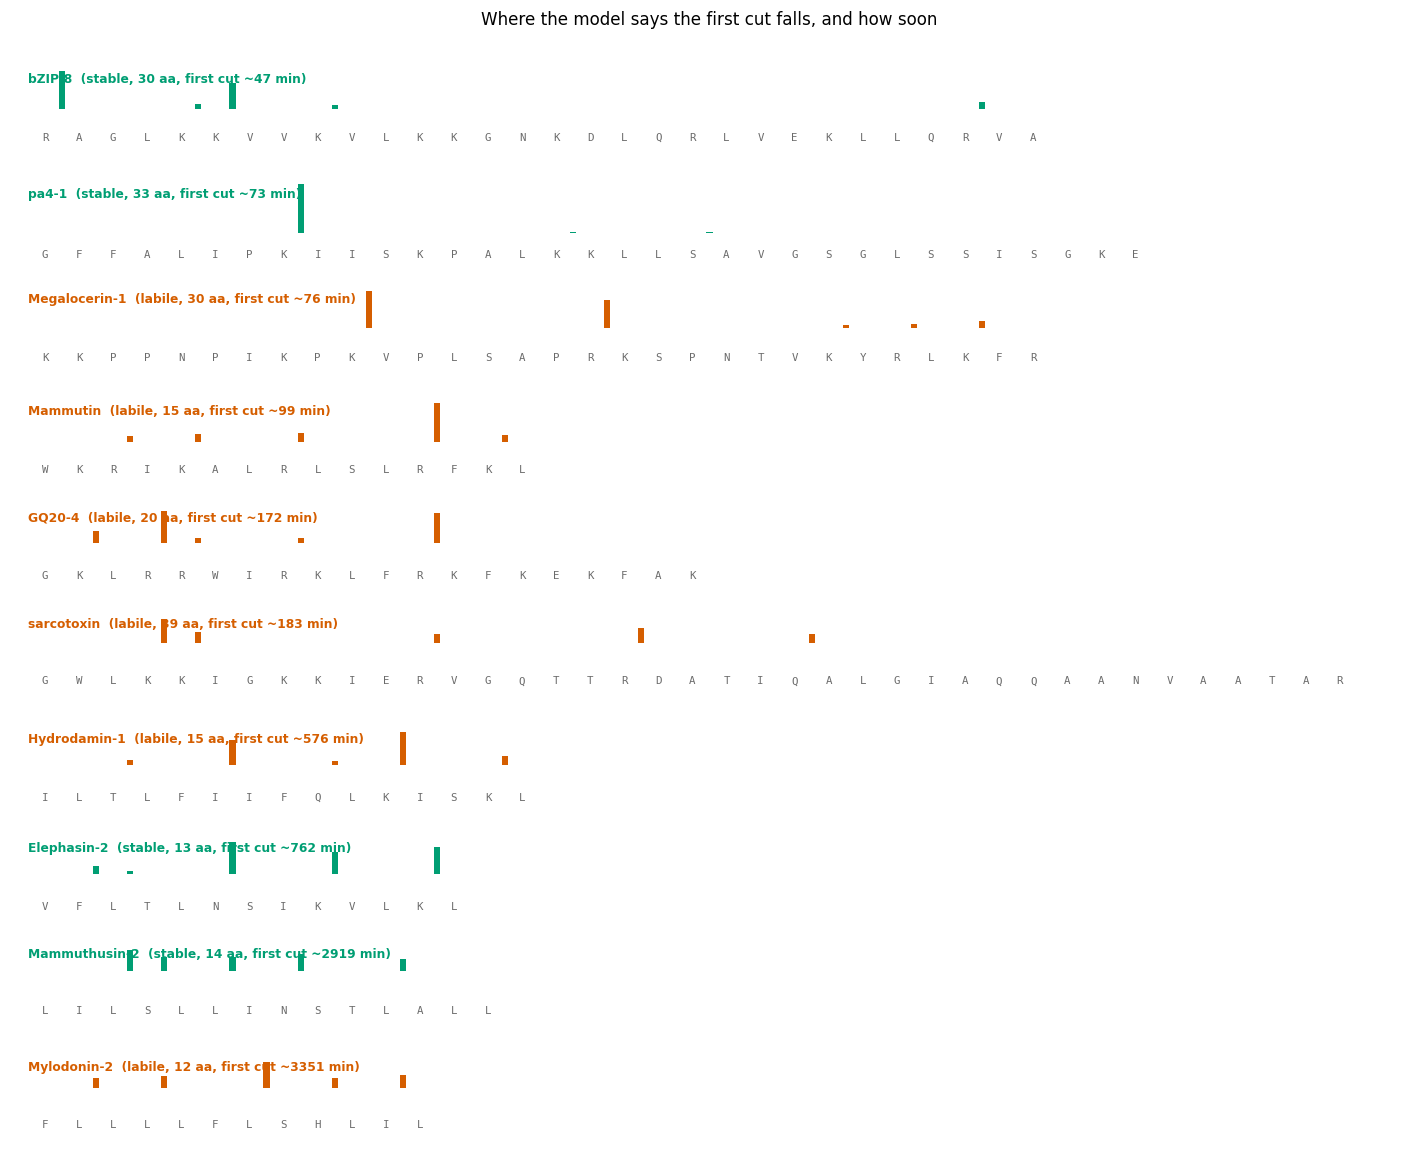

In [5]:
order = (
    cut_sites.groupby("short")["expected_first_cut_minutes"].first().sort_values().index.tolist()
)
fig, axes = plt.subplots(len(order), 1, figsize=(13.0, 1.05 * len(order)), sharex=False)
for ax, short in zip(axes, order):
    record = controls[controls["short"] == short].iloc[0]
    sequence = record["sequence"]
    group = cut_sites[cut_sites["short"] == short]
    fate = record["serum_fate"]
    colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
    for position, residue in enumerate(sequence):
        ax.text(position, -0.28, residue, ha="center", va="top", fontsize=7, family="monospace",
                color=common.NEUTRAL)
    for row in group.itertuples():
        ax.bar(row.bond + 0.5, row.probability, width=0.18, color=colour)
    ax.set_xlim(-1, max(controls["length"]) + 1)
    ax.set_ylim(-0.55, max(0.05, group["probability"].max() * 1.25))
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ("top", "right", "bottom", "left"):
        ax.spines[spine].set_visible(False)
    ax.text(-0.5, group["probability"].max() * 0.8 if len(group) else 0.03,
            f"{short}  ({fate}, {int(record['length'])} aa, first cut ~{group['expected_first_cut_minutes'].iloc[0]:.0f} min)",
            ha="left", va="center", fontsize=8,
            color=colour, fontweight="bold")
fig.suptitle("Where the model says the first cut falls, and how soon", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

**Provenance**

`controls_mic.csv` supplies the named control sequence, serum-fate annotation and MIC; MEROPS 2023 matrices, `results/2_07_model_panel.csv`, and `results/3_01_time_axis_calibration.csv` supply the modelled site scores and provisional time scale. Code cell 6 enumerates admissible bonds and exact first-cut probabilities for each control; `results/4_05_cut_sites.csv` preserves these bond-level records. One vertical bar is one candidate bond within one peptide, not a directly observed cleavage. Check the bond and protease columns in that table and the source control row. The annotation's original publication/table locator is not stored in `controls_mic.csv`: TODO: provenance do ustalenia.


## Watching the molecules over a day

Two hundred molecules of each peptide are followed for twenty-four hours. Three
quantities are recorded on a log time grid: the share still uncut, the potency of
the mixture relative to the intact peptide, and the effective MIC that mixture
would show.

In [6]:
survival_rows = []
fragment_rows = []
for row in controls.itertuples():
    sequence = row.sequence
    parent_mic = mic_of.get(sequence)
    if parent_mic is None or parent_mic <= 0:
        continue
    dose = DOSE_MULTIPLE * float(parent_mic)
    intact = state_potency(sequence, (Fragment(0, len(sequence)),), dose)
    potency_curves = np.empty((N_TRAJECTORIES, len(times)))
    uncut = np.zeros((N_TRAJECTORIES, len(times)), dtype=bool)
    final_fragments: dict[str, float] = {}
    for replicate in range(N_TRAJECTORIES):
        steps = simulate_trajectory(
            sequence, kinetics, np.random.default_rng(rng.integers(0, 2**32 - 1)),
            float(times[-1]), human_background, max_events=MAX_EVENTS,
        )
        for index, time in enumerate(times):
            state = state_at(steps, time)
            potency_curves[replicate, index] = state_potency(sequence, state, dose)
            uncut[replicate, index] = len(state) == 1
        for fragment in state_at(steps, float(times[-1])):
            piece = sequence[fragment.start : fragment.end]
            mic = mic_of.get(piece) if len(piece) >= MIN_ACTIVE_LENGTH else None
            final_fragments[f"{fragment.start + 1}-{fragment.end}"] = final_fragments.get(
                f"{fragment.start + 1}-{fragment.end}", 0.0
            ) + (dose / float(mic) if mic else 0.0)

    mean_potency = potency_curves.mean(axis=0) / intact
    survival_rows.append(
        pd.DataFrame(
            {
                "short": row.short, "serum_fate": row.serum_fate, "length": row.length,
                "minute": times, "share_uncut": uncut.mean(axis=0),
                "relative_potency": mean_potency,
                "effective_mic": np.where(mean_potency > 0, float(parent_mic) / mean_potency, np.inf),
            }
        )
    )
    for span, contribution in final_fragments.items():
        fragment_rows.append(
            {"short": row.short, "serum_fate": row.serum_fate, "span": span,
             "share_of_intact": contribution / (intact * N_TRAJECTORIES)}
        )

survival = pd.concat(survival_rows, ignore_index=True)
fragment_shares = pd.DataFrame(fragment_rows)

checkpoints = []
for short, group in survival.groupby("short"):
    record = {"short": short, "serum_fate": group["serum_fate"].iloc[0], "length": group["length"].iloc[0]}
    for checkpoint in CHECKPOINTS_MINUTES:
        nearest = group.iloc[(group["minute"] - checkpoint).abs().argmin()]
        label = f"{checkpoint / 60:.0f}h" if checkpoint >= 60 else f"{checkpoint:.0f}min"
        record[f"uncut_{label}"] = float(nearest["share_uncut"])
        record[f"potency_{label}"] = float(nearest["relative_potency"])
    checkpoints.append(record)
checkpoint_frame = pd.DataFrame(checkpoints).sort_values("potency_24h")

print("share of molecules still uncut, and potency retained, at each checkpoint:")
print(checkpoint_frame.round(3).to_string(index=False))

share of molecules still uncut, and potency retained, at each checkpoint:
        short serum_fate  length  uncut_30min  potency_30min  uncut_1h  potency_1h  uncut_4h  potency_4h  uncut_12h  potency_12h  uncut_24h  potency_24h
     Mammutin     labile      15        0.760          0.876     0.565       0.753     0.055       0.258      0.005        0.033      0.000        0.005
       GQ20-4     labile      20        0.830          0.971     0.735       0.946     0.275       0.742      0.010        0.205      0.000        0.021
 Hydrodamin-1     labile      15        0.945          0.968     0.905       0.951     0.635       0.773      0.250        0.453      0.060        0.206
  Elephasin-2     stable      13        0.975          0.979     0.940       0.947     0.710       0.737      0.380        0.428      0.165        0.210
       bZIP-8     stable      30        0.525          0.821     0.305       0.720     0.005       0.495      0.000        0.399      0.000        0.298
Megaloce

### Reading the figure

Left: the share of molecules still intact, against time on a log axis. A peptide
that holds stays near the top; one that falls apart drops. Right: the effective
MIC of what is left, which begins at the measured MIC and rises as the molecule is
destroyed. Green is annotated stable, orange annotated labile. If the annotation
corresponded to what the model does, the green curves would sit above the orange
ones on the left and below them on the right.

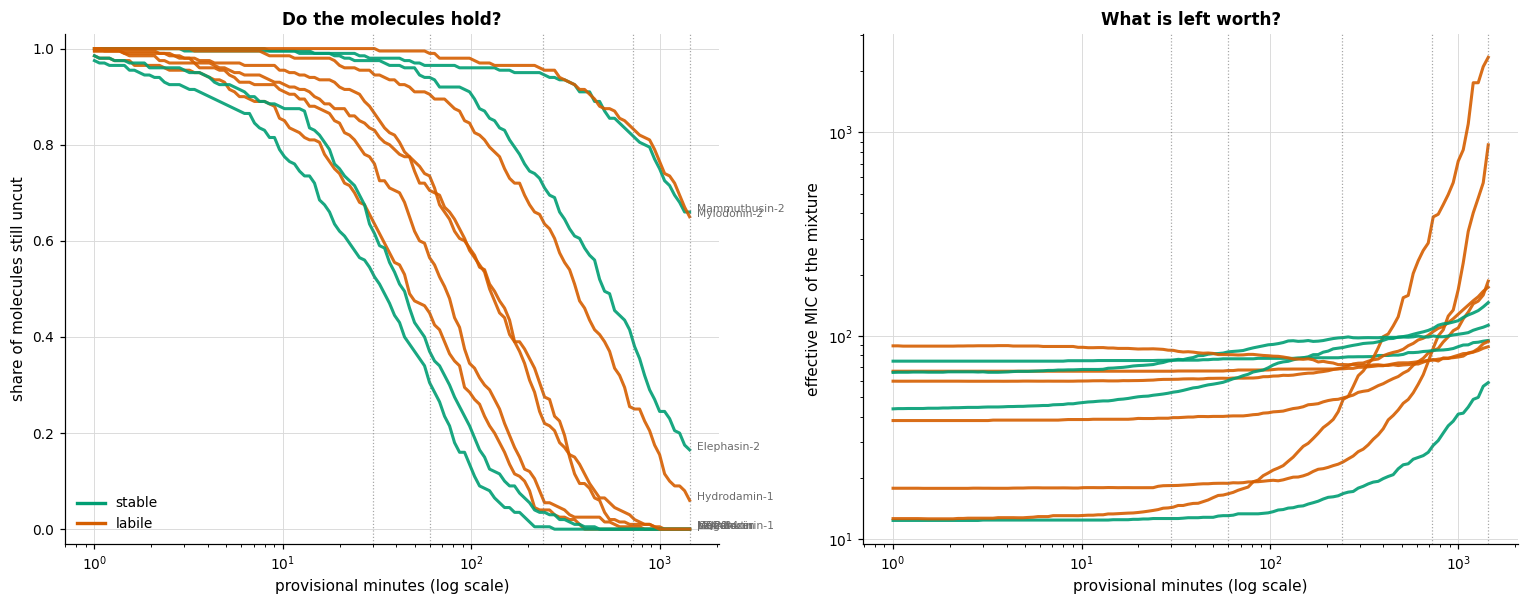

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.6))
for short, group in survival.groupby("short"):
    fate = group["serum_fate"].iloc[0]
    colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
    positive = group[group["minute"] > 0]
    axes[0].plot(positive["minute"], positive["share_uncut"], color=colour, linewidth=2.0, alpha=0.9)
    axes[0].annotate(short, (positive["minute"].iloc[-1], positive["share_uncut"].iloc[-1]),
                     textcoords="offset points", xytext=(5, 0), fontsize=7, color=common.NEUTRAL)
    axes[1].plot(positive["minute"], positive["effective_mic"], color=colour, linewidth=2.0, alpha=0.9)
for ax, label, title in (
    (axes[0], "share of molecules still uncut", "Do the molecules hold?"),
    (axes[1], "effective MIC of the mixture", "What is left worth?"),
):
    ax.set_xscale("log")
    for checkpoint in CHECKPOINTS_MINUTES:
        ax.axvline(checkpoint, color=common.NEUTRAL, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("provisional minutes (log scale)")
    ax.set_ylabel(label)
    ax.set_title(title)
axes[0].set_ylim(-0.03, 1.03)
axes[1].set_yscale("log")
handles = [
    plt.Line2D([], [], color=colour, linewidth=2.2, label=fate)
    for fate, colour in (("stable", common.CATEGORICAL_COLORS[2]), ("labile", common.CATEGORICAL_COLORS[1]))
]
axes[0].legend(handles=handles, frameon=False, fontsize=9, loc="lower left")
fig.tight_layout()
plt.show()

**Provenance**

Code cell 11 simulates intact and fragmented molecules for each labelled control on the fixed time grid and seed, applying `APEXPredictor` to fragment states. `results/4_05_survival.csv` contains the time-by-peptide summaries and `4_05_fragment_shares.csv` decomposes the remaining fragments. One plotted trajectory is an aggregate over simulated molecules for one peptide; the data are model outputs, not experimentally measured survival fractions or MIC at each time. Inspect code cell 11 for the trajectory count and potency sum. The time axis inherits the unvalidated calibration from `3_01`.


## The direct comparison, without a statistic

The checkpoint table above, read as a picture: every peptide at every checkpoint,
ordered by how much potency it retains at twenty-four hours. If the annotation
meant what it says, the green rows would gather at one end.

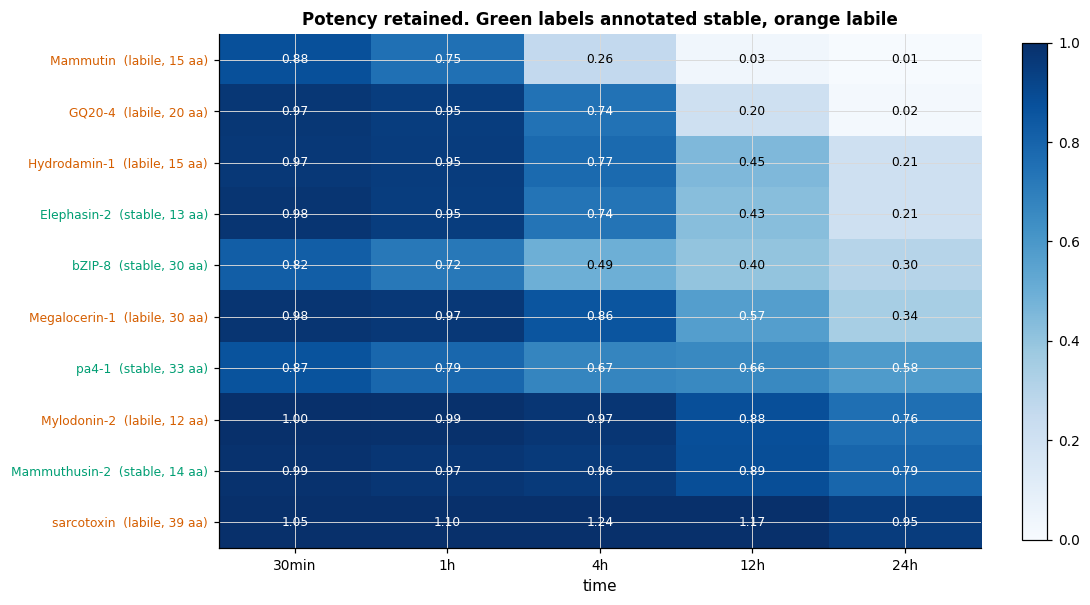

In [8]:
fig, ax = plt.subplots(figsize=(10.0, 5.6))
labels = [f"{c / 60:.0f}h" if c >= 60 else f"{c:.0f}min" for c in CHECKPOINTS_MINUTES]
matrix = checkpoint_frame[[f"potency_{label}" for label in labels]].to_numpy()
image = ax.imshow(matrix, aspect="auto", vmin=0, vmax=1, cmap=common.SEQUENTIAL_CMAP)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(checkpoint_frame)))
ax.set_yticklabels(
    [f"{row.short}  ({row.serum_fate}, {int(row.length)} aa)" for row in checkpoint_frame.itertuples()],
    fontsize=8,
)
for tick, row in zip(ax.get_yticklabels(), checkpoint_frame.itertuples()):
    tick.set_color(common.CATEGORICAL_COLORS[2] if row.serum_fate == "stable" else common.CATEGORICAL_COLORS[1])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if matrix[i, j] > 0.55 else "black")
ax.set_xlabel("time")
ax.set_title("Potency retained. Green labels annotated stable, orange labile")
fig.colorbar(image, ax=ax, fraction=0.03)
fig.tight_layout()
plt.show()

## The difference, in units that mean something

No rank statistic appears in this section. A statistic like an AUC answers "how
often is a labile peptide higher than a stable one", which is a true sentence about
orderings and tells nobody how much anything differs. Nothing is being classified
here and no threshold is being set, so the honest quantities are the ones with
units on them:

* **how many minutes** a peptide takes to lose half its activity;
* **what percentage** of its activity is left after an hour, four hours, a day;
* **how many times** larger the one group's value is than the other's;
* whether the two groups' ranges **overlap at all**, which is the question a
  summary statistic hides most effectively.

In [9]:
def minutes_to_fraction(group: pd.DataFrame, fraction: float) -> float:
    """Return the first time at which the retained potency falls to a fraction.

    :param group: Survival rows for one peptide, ordered by time.
    :param fraction: Fraction of the intact potency.
    :return: Minutes, or infinity when it never falls that far.
    """

    below = group[group["relative_potency"] <= fraction]
    return float(below["minute"].min()) if len(below) else float("inf")


plain_rows = []
for short, group in survival.groupby("short"):
    group = group.sort_values("minute")
    record = controls[controls["short"] == short].iloc[0]
    hour = group.iloc[(group["minute"] - 60.0).abs().argmin()]
    four = group.iloc[(group["minute"] - 240.0).abs().argmin()]
    day = group.iloc[(group["minute"] - 1440.0).abs().argmin()]
    plain_rows.append(
        {
            "peptide": short,
            "annotation": record["serum_fate"],
            "length": int(record["length"]),
            "minutes_to_lose_half": minutes_to_fraction(group, 0.5),
            "minutes_to_lose_10_percent": minutes_to_fraction(group, 0.9),
            "percent_left_1h": 100.0 * float(hour["relative_potency"]),
            "percent_left_4h": 100.0 * float(four["relative_potency"]),
            "percent_left_24h": 100.0 * float(day["relative_potency"]),
            "percent_uncut_24h": 100.0 * float(day["share_uncut"]),
        }
    )
plain = pd.DataFrame(plain_rows).sort_values("percent_left_24h")
print("what actually happens to each peptide, in plain units:")
print(plain.round(1).to_string(index=False))

## The group comparison, as a ratio and as an overlap rather than as a rank statistic
comparison_rows = []
for column, unit in (
    ("minutes_to_lose_half", "minutes"),
    ("minutes_to_lose_10_percent", "minutes"),
    ("percent_left_1h", "percent"),
    ("percent_left_4h", "percent"),
    ("percent_left_24h", "percent"),
):
    stable_values = plain.loc[plain["annotation"] == "stable", column].replace(np.inf, np.nan).dropna()
    labile_values = plain.loc[plain["annotation"] == "labile", column].replace(np.inf, np.nan).dropna()
    if len(stable_values) == 0 or len(labile_values) == 0:
        continue
    ## Do the two groups occupy disjoint ranges, or does each contain the other's?
    overlap = not (stable_values.min() > labile_values.max() or labile_values.min() > stable_values.max())
    comparison_rows.append(
        {
            "quantity": column,
            "unit": unit,
            "stable_median": float(stable_values.median()),
            "labile_median": float(labile_values.median()),
            "fold_difference": float(stable_values.median() / labile_values.median())
            if labile_values.median() else np.nan,
            "stable_range": f"{stable_values.min():.0f} to {stable_values.max():.0f}",
            "labile_range": f"{labile_values.min():.0f} to {labile_values.max():.0f}",
            "ranges_overlap": overlap,
        }
    )
plain_comparison = pd.DataFrame(comparison_rows)
print()
print("the two annotated groups, compared without a rank statistic:")
print(plain_comparison.round(2).to_string(index=False))

n_infinite = int(np.isinf(plain["minutes_to_lose_half"]).sum())
print(f"\npeptides that never lose half their activity within {HORIZON_MINUTES / 60:.0f} h: "
      f"{n_infinite} of {len(plain)}")

what actually happens to each peptide, in plain units:
      peptide annotation  length  minutes_to_lose_half  minutes_to_lose_10_percent  percent_left_1h  percent_left_4h  percent_left_24h  percent_uncut_24h
     Mammutin     labile      15                 132.8                        27.1             75.3             25.8               0.5                0.0
       GQ20-4     labile      20                 424.2                       124.9             94.6             74.2               2.1                0.0
 Hydrodamin-1     labile      15                 650.6                       117.5             95.1             77.3              20.6                6.0
  Elephasin-2     stable      13                 612.1                       110.6             94.7             73.7              21.0               16.5
       bZIP-8     stable      30                 230.2                        14.7             72.0             49.5              29.8                0.0
Megalocerin-1     lab

### Reading the figure

Each peptide is a horizontal bar: how much of its activity is left after one hour,
four hours and a day, in per cent. Green bars are annotated stable, orange labile.
The question needs no statistic — either the green bars are longer than the orange
ones or they are not.

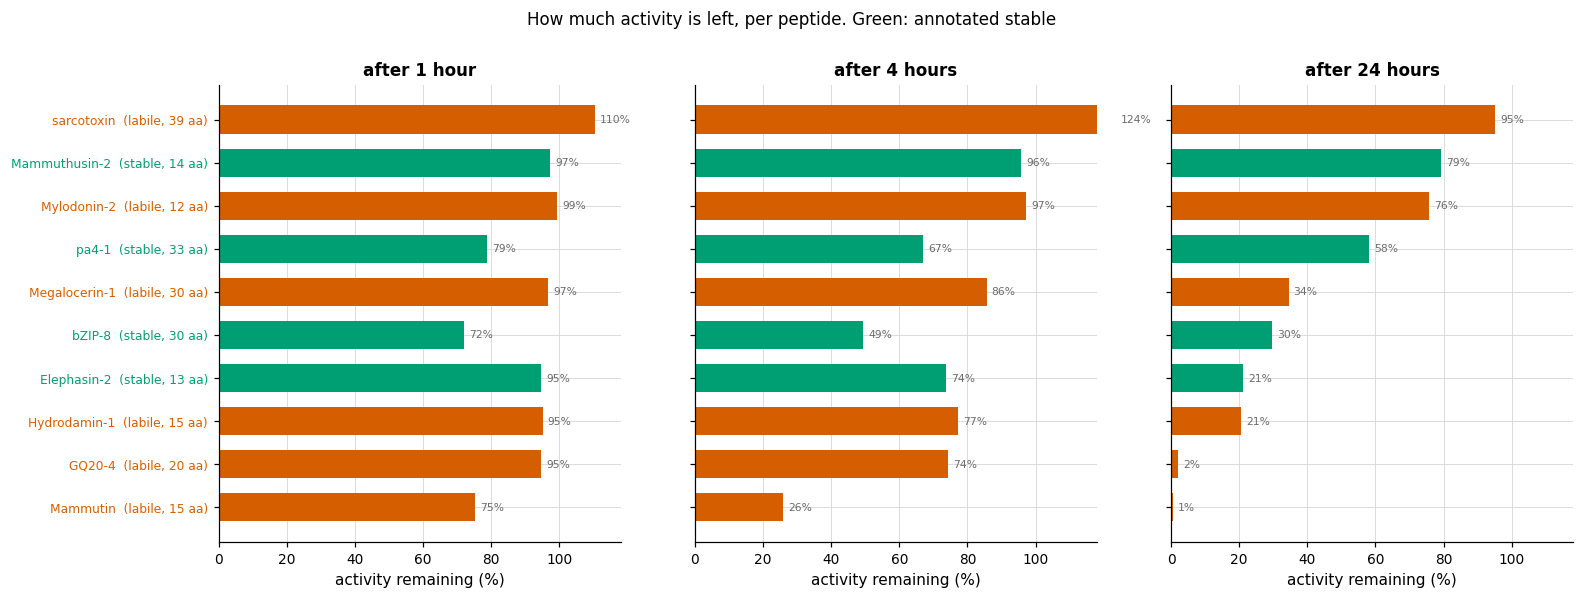

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.4), sharey=True)
ordered = plain.sort_values("percent_left_24h", ascending=False).reset_index(drop=True)
for ax, column, title in (
    (axes[0], "percent_left_1h", "after 1 hour"),
    (axes[1], "percent_left_4h", "after 4 hours"),
    (axes[2], "percent_left_24h", "after 24 hours"),
):
    colours = [
        common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
        for fate in ordered["annotation"]
    ]
    ax.barh(range(len(ordered)), ordered[column], color=colours, height=0.66)
    for position, value in enumerate(ordered[column]):
        ax.text(value + 1.5, position, f"{value:.0f}%", va="center", fontsize=7, color=common.NEUTRAL)
    ax.set_xlim(0, 118)
    ax.invert_yaxis()
    ax.set_xlabel("activity remaining (%)")
    ax.set_title(title)
axes[0].set_yticks(range(len(ordered)))
axes[0].set_yticklabels(
    [f"{row.peptide}  ({row.annotation}, {row.length} aa)" for row in ordered.itertuples()], fontsize=8
)
for tick, fate in zip(axes[0].get_yticklabels(), ordered["annotation"]):
    tick.set_color(common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1])
fig.suptitle("How much activity is left, per peptide. Green: annotated stable", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

**Provenance**

`results/4_05_plain_units.csv` converts the same simulated trajectories into retained-activity percentages at stated checkpoints, and `4_05_group_comparison.csv` aggregates the stable/labile annotations. Code cells 18–20 define the first threshold-crossing rule and the percentage denominators. One bar is one labelled peptide at one checkpoint; percentages are relative to its modelled initial activity. These units make model contrasts readable but do not make the predictions observed serum stability measurements.


In [11]:
common.save_result(plain, "4_05_plain_units.csv")
common.save_result(plain_comparison, "4_05_group_comparison.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_05_group_comparison.csv')

In [12]:
common.save_result(survival, "4_05_survival.csv")
common.save_result(checkpoint_frame, "4_05_checkpoints.csv")
common.save_result(cut_sites, "4_05_cut_sites.csv")
common.save_result(fragment_shares, "4_05_fragment_shares.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_05_fragment_shares.csv')

## Findings and decisions

No rank statistic is used below. Every number has a unit.

### What happens to each peptide

| peptide | annotation | length | min to lose 10% | min to lose half | left at 24 h |
| --- | --- | --- | --- | --- | --- |
| Mammutin | labile | 15 | 27 | **133** | **0.5%** |
| bZIP-8 | **stable** | 30 | **15** | 230 | 30% |
| GQ20-4 | labile | 20 | 125 | 424 | 2% |
| Elephasin-2 | **stable** | 13 | 111 | 612 | 21% |
| Hydrodamin-1 | labile | 15 | 118 | 651 | 21% |
| Megalocerin-1 | labile | 30 | 192 | 939 | 35% |
| pa4-1 | **stable** | 33 | 26 | never | 58% |
| Mylodonin-2 | labile | 12 | 612 | never | 76% |
| Mammuthusin-2 | **stable** | 14 | 651 | never | 79% |
| sarcotoxin | labile | 39 | never | never | **95%** |

### The two groups compared, in units

| quantity | stable median | labile median | ratio | ranges overlap |
| --- | --- | --- | --- | --- |
| minutes to lose 10% | 68 | 125 | **0.54** | yes |
| minutes to lose half | 421 | 537 | **0.78** | yes |
| % left at 1 h | 86.7 | 95.9 | 0.90 | yes |
| % left at 4 h | 70.4 | 81.5 | 0.86 | yes |
| % left at 24 h | 44.0 | 27.6 | **1.60** | yes |

### The model contradicts itself between early and late

**Early, the direction is wrong.** An annotated-stable peptide loses its first 10%
of activity in a median of **68 minutes**; an annotated-labile one takes **125**.
The stable peptides are attacked roughly **twice as fast**. The same holds at every
checkpoint up to four hours.

**Late, the direction is right.** At twenty-four hours the stable peptides retain
**44%** against **28%**, a ratio of 1.6 the correct way round.

The two are not in conflict; they are governed by different things, and separating
them is what this notebook adds.

* The **early rate** is the hazard, which `3_04` showed is nearly a ranking by
  length. The two fastest-attacked peptides in the panel are bZIP-8 (30 aa, 10% lost
  in 15 minutes) and pa4-1 (33 aa, 26 minutes) — both annotated stable, both long,
  both simply offering more bonds.
* The **late plateau** is what the fragments are worth. Those same two long peptides
  retain 30% and 58% at a day, because cutting them leaves pieces that are still
  above the length guard and still potent. The two shortest peptides, Mylodonin-2
  (12 aa) and Mammuthusin-2 (14 aa), are barely touched at all.

So the model says: long peptides are cut sooner and survive it better; short
peptides are cut later and are destroyed when they are. The annotation is
confounded with length in opposite directions between its two sources (`3_03`),
which is why it lines up with neither half of that behaviour consistently.

### The separation is never clean

**Every quantity has overlapping ranges.** At twenty-four hours the labile peptides
span 0.5% to 95% and the stable ones 21% to 79% — the labile range strictly
*contains* the stable one. The best-preserved peptide in the whole panel, sarcotoxin
at 95%, is annotated labile; the worst, Mammutin at 0.5%, is also labile.

Given one peptide and its predicted curve, its group cannot be named. That is the
statement an AUC of 0.42 was making and failing to communicate.

### One defect is visible here that the aggregates hid

Sarcotoxin's retained potency **exceeds 100%** at intermediate times — 111% at one
hour, 124% at four. Cleaving it *raises* the potency sum, because every fragment
inherits the parent's molar concentration. This is the mixture-rule defect `4_03`
identified on the aureolysin digest of LL-37, still present in the chain, and it is
why sarcotoxin appears as the most durable peptide in the panel.

### The correlation with length is weaker here than for the hazard

Retained potency at twenty-four hours correlates with length at Spearman **+0.195**,
against **+0.76 to +1.00** for the raw hazard (`3_04`). The fragment cascade and the
fragment MICs therefore add something beyond the bond count — which is the first
evidence in the series that the cut-to-MIC layer is not simply length in disguise.